In [1]:
import numpy as np
from pyvrp import Model, solve
from pyvrp.stop import MaxRuntime
import pyvrp.plotting

In [17]:
def solve_w_elevation_penalty(elevation_data_scale=1, unit_distance_cost=1, unit_elevation_cost=1):
    # Create a realistic instance
    rng = np.random.default_rng(42)
    model = Model()

    depot = model.add_depot(x=0, y=0, elevation=0)
    depot2 = model.add_depot(x=400, y=300, elevation=int(4*30*elevation_data_scale))

    # Create 15 clients arranged in a grid
    # Elevation increases to the east
    clients = []
    for i in range(15):
        row = i // 5
        col = i % 5

        x = col * 100
        y = row * 100

        # Elevation increases with column (east direction)
        elevation = col * 30  # 0, 30, 60, 90, 120 meters

        delivery = int(rng.integers(10, 20))

        client = model.add_client(
            x=x,
            y=y,
            delivery=[delivery],
            elevation=int(elevation*elevation_data_scale)
        )
        clients.append(client)

    # Vehicle type
    total_demand = sum(c.delivery[0] for c in clients)
    model.add_vehicle_type(
        num_available=1,
        capacity=[int(total_demand / 2)],
        start_depot=depot,
        end_depot=depot,
        unit_distance_cost=unit_distance_cost,
        unit_elevation_cost=unit_elevation_cost,
        
    )
    model.add_vehicle_type(
        num_available=1,
        capacity=[int(total_demand / 2)],
        start_depot=depot2,
        end_depot=depot2,
        unit_distance_cost=unit_distance_cost,
        unit_elevation_cost=unit_elevation_cost,
    )

    for frm_idx, frm in enumerate(model.locations):
        for to_idx, to in enumerate(model.locations):
            duration = np.sqrt((frm.x - to.x)**2 + (frm.y - to.y)**2)
            model.add_edge(frm, to, distance=duration, duration=duration)

    data = model.data()

    result = solve(
        data,
        stop=MaxRuntime(3.0),
        seed=42,
        display=False
    )

    print(f"\nSolution:")
    print(f"  Cost (unpenalized): {result.cost():.0f}")
    print(f"  Distance: {result.best.distance()}")
    print(f"  Elevation cost: {result.best.elevation_cost()}")
    print(f"  Number of routes: {len(result.best.routes())}")
    print(f"  Iterations: {result.num_iterations}")

    print(f"\nRoutes:")
    for idx, route in enumerate(result.best.routes(), 1):
        visits = [data.location(c) for c in route.visits()]
        elevs = [v.elevation for v in visits]

        # Compute climb
        total_climb = sum(max(0, elevs[i+1] - elevs[i])
                         for i in range(len(elevs) - 1))/elevation_data_scale

        print(f"  Route {idx}:")
        print(f"    Clients: {len(route.visits()) - 2}")
        print(f"    Load: {route.delivery()[0]} kg")
        print(f"    Elevation cost: {route.elevation_cost()}")
        print(f"    Total climb: {total_climb}m")

    return model, result



Solution:
  Cost (unpenalized): 1823
  Distance: 1823
  Elevation cost: 0
  Number of routes: 2
  Iterations: 26643

Routes:
  Route 1:
    Clients: 5
    Load: 111 kg
    Elevation cost: 0
    Total climb: 60.0m
  Route 2:
    Clients: 6
    Load: 111 kg
    Elevation cost: 0
    Total climb: 60.0m


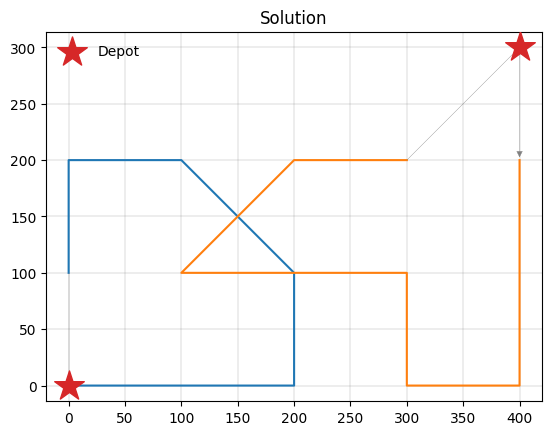

In [19]:
model, result = solve_w_elevation_penalty(unit_elevation_cost=0, unit_distance_cost=1)
pyvrp.plotting.plot_solution(result.best, model.data())


Solution:
  Cost (unpenalized): 5124
  Distance: 2124
  Elevation cost: 3000
  Number of routes: 2
  Iterations: 21451

Routes:
  Route 1:
    Clients: 5
    Load: 111 kg
    Elevation cost: 3000
    Total climb: 60.0m
  Route 2:
    Clients: 6
    Load: 111 kg
    Elevation cost: 0
    Total climb: 0.0m


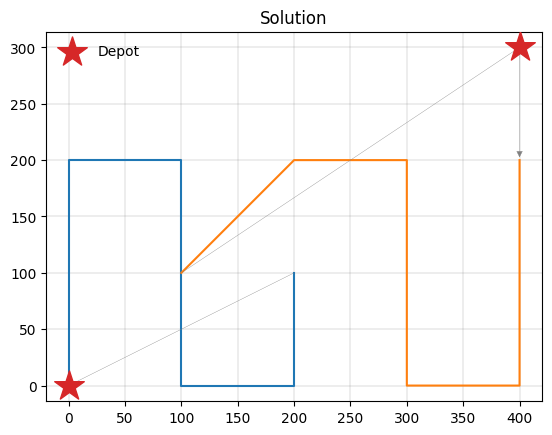

In [20]:
model, result = solve_w_elevation_penalty(unit_elevation_cost=1, unit_distance_cost=1)
pyvrp.plotting.plot_solution(result.best, model.data())


Solution:
  Cost (unpenalized): 11278
  Distance: 1942
  Elevation cost: 3510
  Number of routes: 2
  Iterations: 24309

Routes:
  Route 1:
    Clients: 5
    Load: 111 kg
    Elevation cost: 3510
    Total climb: 60.0m
  Route 2:
    Clients: 6
    Load: 111 kg
    Elevation cost: 0
    Total climb: 0.0m


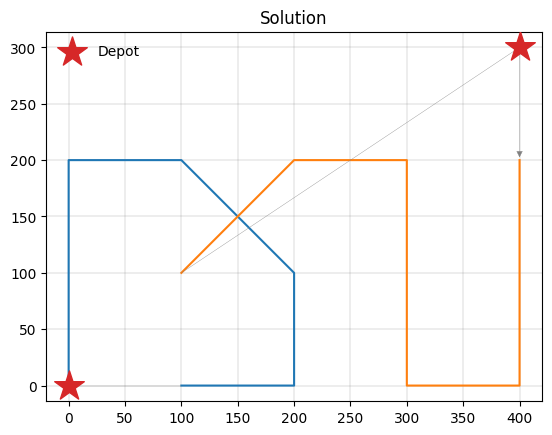

In [21]:
model, result = solve_w_elevation_penalty(unit_elevation_cost=1, unit_distance_cost=4)
pyvrp.plotting.plot_solution(result.best, model.data())